# 📊 Fase 2 — Geração de Dados e Modelo Base de Score de Crédito

**Contexto:** dados reais de concessão de crédito com histórico temporal não são
publicamente disponíveis (sigilo bancário, regulação). Para validar rigorosamente
uma metodologia de monitoramento, geramos dados sintéticos com parâmetros de risco
e um ponto de mudança populacional **conhecidos** — o que permite testar se as
métricas de monitoramento (PSI, KS, AUC) realmente detectam a mudança inserida.

**Cenário simulado:** 24 meses de concessão de crédito. A partir do mês 13,
simulamos uma crise econômica (queda de renda, aumento de uso de crédito e atrasos).


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

np.random.seed(42)

N_MESES = 24
CLIENTES_POR_MES = 600
MES_INICIO_CRISE = 13


In [2]:
import os
os.chdir("/workspaces/monitor-credito-llm")
print("Diretório atual:", os.getcwd())

Diretório atual: /workspaces/monitor-credito-llm


## 1. Função geradora de safras

Cada "mês" gera um novo lote de clientes, com uma regra de risco conhecida por nós.

In [3]:
def gerar_safra(mes, n, em_crise):
    renda = np.random.lognormal(mean=8.2 if not em_crise else 8.0, sigma=0.45, size=n)
    idade = np.random.normal(38, 11, n).clip(18, 75)
    tempo_emprego = np.random.exponential(5 if not em_crise else 3.5, n).clip(0, 40)
    divida_existente = np.random.gamma(2, 1500 if not em_crise else 2200, n)
    utilizacao_credito = np.random.beta(2, 5 if not em_crise else 3.5, n)
    atrasos_12m = np.random.poisson(0.4 if not em_crise else 0.9, n).clip(0, 12)
    valor_emprestimo = np.random.lognormal(mean=8.5, sigma=0.5, size=n)

    df = pd.DataFrame({
        "mes": mes,
        "idade": idade.round(0),
        "renda_mensal": renda.round(2),
        "tempo_emprego_anos": tempo_emprego.round(1),
        "divida_existente": divida_existente.round(2),
        "utilizacao_credito": utilizacao_credito.round(3),
        "atrasos_12m": atrasos_12m,
        "valor_emprestimo": valor_emprestimo.round(2),
    })

    # Regra de risco "verdadeira" -- definida por nos, serve de gabarito
    z = (
        -0.35 * (df["renda_mensal"] - 3600) / 1200
        + 0.30 * (df["divida_existente"] - 3000) / 2000
        + 1.8 * df["utilizacao_credito"]
        + 0.65 * df["atrasos_12m"]
        - 0.30 * (df["tempo_emprego_anos"] - 5) / 5
        - 0.15 * (df["idade"] - 38) / 12
        + 0.15 * (df["valor_emprestimo"] - 5500) / 2500
        - 3.1
    )
    prob_default = 1 / (1 + np.exp(-z))
    df["prob_default_real"] = prob_default
    df["default"] = np.random.binomial(1, prob_default)
    return df


## 2. Gerando as 24 safras

In [4]:
safras = [
    gerar_safra(mes, CLIENTES_POR_MES, em_crise=(mes >= MES_INICIO_CRISE))
    for mes in range(1, N_MESES + 1)
]
df_total = pd.concat(safras, ignore_index=True)
print(f"Total de registros: {len(df_total)}")
df_total.head()


Total de registros: 14400


,mes,idade,renda_mensal,tempo_emprego_anos,divida_existente,utilizacao_credito,atrasos_12m,valor_emprestimo,prob_default_real,default
0,1,46.0,4552.91,0.2,5946.61,0.137,0,9090.59,0.092297,0
1,1,28.0,3421.32,5.0,2455.98,0.449,0,3371.35,0.089154,0
2,1,48.0,4872.97,15.1,4506.74,0.252,0,5951.07,0.029437,0
3,1,53.0,7225.44,4.6,3715.24,0.170,0,8625.40,0.023658,0
4,1,43.0,3276.83,8.6,1815.51,0.080,1,2056.20,0.053426,0


## 3. Conferindo se a simulação ficou realista

In [5]:
print("Taxa de inadimplência por mês:")
print(df_total.groupby("mes")["default"].mean().round(3))

print("\nComparação antes/depois da crise:")
comparacao = df_total.groupby(df_total["mes"] >= MES_INICIO_CRISE).agg(
    renda_media=("renda_mensal", "mean"),
    utilizacao_media=("utilizacao_credito", "mean"),
    taxa_default=("default", "mean"),
).round(3)
comparacao.index = ["Antes da crise", "Durante a crise"]
comparacao


Taxa de inadimplência por mês:
mes
1     0.088
2     0.090
3     0.095
4     0.103
5     0.098
6     0.118
7     0.097
8     0.092
9     0.108
10    0.113
11    0.097
12    0.102
13    0.227
14    0.208
15    0.230
16    0.222
17    0.260
18    0.255
19    0.238
20    0.223
21    0.237
22    0.245
23    0.228
24    0.235
Name: default, dtype: float64

Comparação antes/depois da crise:


,renda_media,utilizacao_media,taxa_default
Antes da crise,4023.184,0.286,0.100
Durante a crise,3306.018,0.363,0.234


## 4. Treinando o modelo base

O modelo é treinado **só com os primeiros 12 meses** (antes da crise) — simulando
um modelo real, que foi desenvolvido com dados históricos e colocado em produção
sem saber que uma mudança de cenário estava por vir.

In [6]:
VARIAVEIS = ["idade", "renda_mensal", "tempo_emprego_anos", "divida_existente",
             "utilizacao_credito", "atrasos_12m", "valor_emprestimo"]

treino = df_total[df_total["mes"] <= 12]
X_treino = treino[VARIAVEIS]
y_treino = treino["default"]

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_treino, y_treino)

score_treino = modelo.predict_proba(X_treino)[:, 1]
auc_treino = roc_auc_score(y_treino, score_treino)
print(f"AUC no treino (meses 1-12): {auc_treino:.3f}")

df_total["score"] = modelo.predict_proba(df_total[VARIAVEIS])[:, 1]


AUC no treino (meses 1-12): 0.732


## 5. Primeira olhada: o modelo se mantém discriminativo?

Vamos calcular o AUC mês a mês, incluindo os meses de crise (que o modelo nunca viu).

In [7]:
auc_por_mes = {}
for mes in range(1, N_MESES + 1):
    m = df_total[df_total["mes"] == mes]
    auc_por_mes[mes] = roc_auc_score(m["default"], m["score"])

auc_series = pd.Series(auc_por_mes, name="auc")
auc_series


1     0.784140
2     0.721103
3     0.657459
4     0.695287
5     0.731539
6     0.788466
7     0.674132
8     0.744187
9     0.725406
10    0.726642
11    0.764156
12    0.752456
13    0.768620
14    0.762644
15    0.761685
16    0.761669
17    0.751112
18    0.771286
19    0.767670
20    0.761482
21    0.769451
22    0.804163
23    0.742949
24    0.763176
Name: auc, dtype: float64

## 6. Calculando PSI e KS por safra

Além do AUC, vamos calcular:
- **PSI**: mede se a distribuição do *score* mudou em relação ao período de treino
- **KS**: mede o quanto o modelo separa bons e maus pagadores dentro de cada safra

In [8]:
def calcular_psi(base, atual, n_bins=10):
    _, limites = pd.qcut(base, q=n_bins, retbins=True, duplicates="drop")
    limites[0] = -np.inf
    limites[-1] = np.inf

    perc_base = pd.cut(base, bins=limites).value_counts(normalize=True, sort=False)
    perc_atual = pd.cut(atual, bins=limites).value_counts(normalize=True, sort=False)

    perc_base = perc_base.replace(0, 0.0001)
    perc_atual = perc_atual.replace(0, 0.0001)

    psi = np.sum((perc_atual - perc_base) * np.log(perc_atual / perc_base))
    return psi

In [9]:
from scipy.stats import ks_2samp

score_base = df_total[df_total["mes"] <= 12]["score"]

resultados = []
for mes in range(1, N_MESES + 1):
    m = df_total[df_total["mes"] == mes]

    psi = calcular_psi(score_base, m["score"])
    ks_stat, _ = ks_2samp(m[m["default"] == 0]["score"], m[m["default"] == 1]["score"])
    auc = roc_auc_score(m["default"], m["score"])

    resultados.append({"mes": mes, "psi": psi, "ks": ks_stat, "auc": auc})

df_metricas = pd.DataFrame(resultados)
df_metricas.round(3)

,mes,psi,ks,auc
0,1,0.007,0.421,0.784
1,2,0.010,0.369,0.721
2,3,0.015,0.261,0.657
3,4,0.009,0.343,0.695
4,5,0.010,0.370,0.732
5,6,0.022,0.469,0.788
6,7,0.011,0.358,0.674
7,8,0.012,0.382,0.744
8,9,0.028,0.369,0.725
9,10,0.006,0.346,0.727


## 7. Visualizando as três métricas ao longo do tempo

In [10]:
import os
print("Diretório atual:", os.getcwd())
print("Existe 'reports/figures'?", os.path.exists("reports/figures"))

Diretório atual: /workspaces/monitor-credito-llm
Existe 'reports/figures'? True


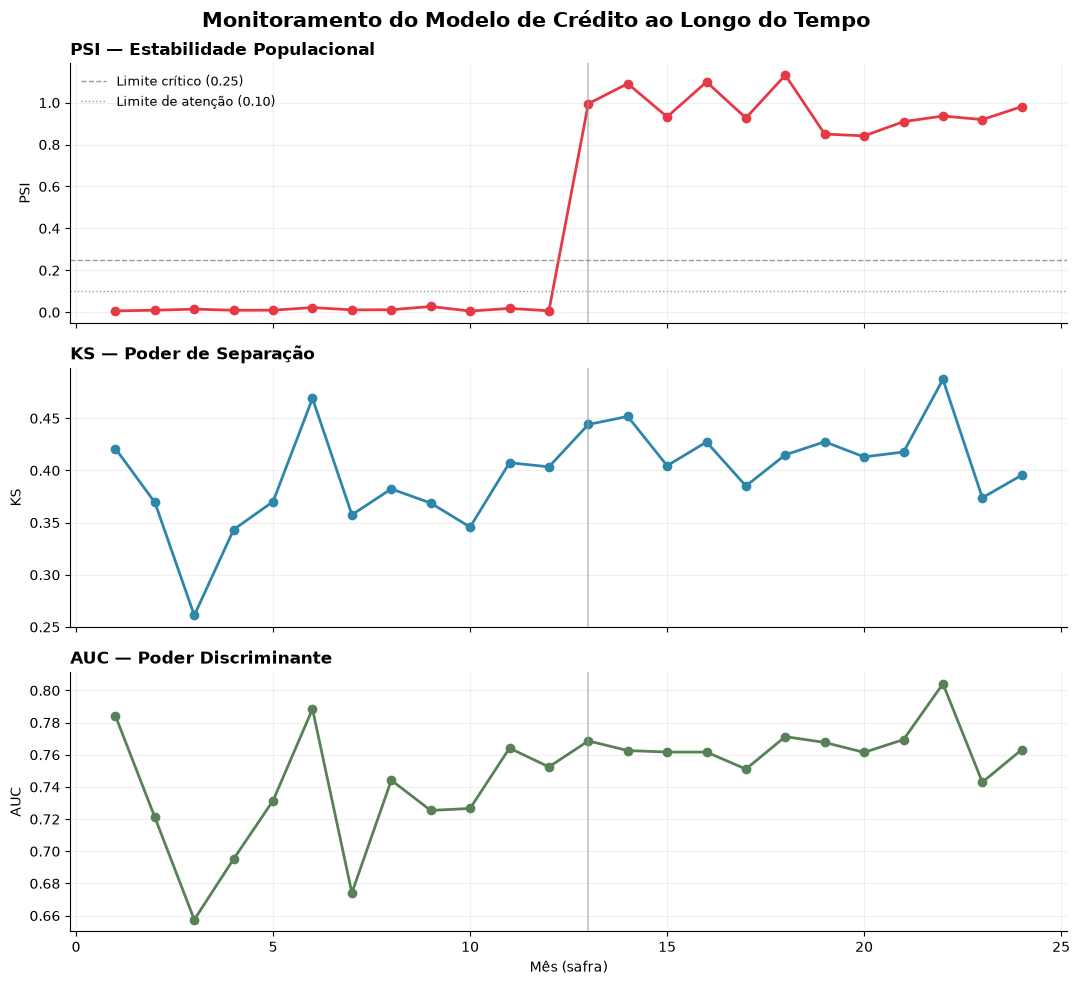

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"
COR_PSI, COR_KS, COR_AUC, COR_CRISE = "#E63946", "#2E86AB", "#588157", "#999999"

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].plot(df_metricas["mes"], df_metricas["psi"], marker="o", color=COR_PSI, linewidth=2)
axes[0].axhline(0.25, linestyle="--", color=COR_CRISE, linewidth=1, label="Limite crítico (0.25)")
axes[0].axhline(0.10, linestyle=":", color=COR_CRISE, linewidth=1, label="Limite de atenção (0.10)")
axes[0].set_ylabel("PSI")
axes[0].set_title("PSI — Estabilidade Populacional", fontsize=12, fontweight="bold", loc="left")
axes[0].legend(loc="upper left", frameon=False, fontsize=9)

axes[1].plot(df_metricas["mes"], df_metricas["ks"], marker="o", color=COR_KS, linewidth=2)
axes[1].set_ylabel("KS")
axes[1].set_title("KS — Poder de Separação", fontsize=12, fontweight="bold", loc="left")

axes[2].plot(df_metricas["mes"], df_metricas["auc"], marker="o", color=COR_AUC, linewidth=2)
axes[2].set_ylabel("AUC")
axes[2].set_xlabel("Mês (safra)")
axes[2].set_title("AUC — Poder Discriminante", fontsize=12, fontweight="bold", loc="left")

for ax in axes:
    ax.axvline(13, color=COR_CRISE, linewidth=1.2, alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.2)

fig.suptitle("Monitoramento do Modelo de Crédito ao Longo do Tempo", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/03_monitoramento_temporal.png", dpi=180, bbox_inches="tight")
plt.show()

In [12]:
df_metricas.to_csv("data/processed/metricas_mensais.csv", index=False)
df_total.to_csv("data/processed/dados_completos.csv", index=False)
print("Dados salvos em data/processed/")

Dados salvos em data/processed/


## Próximos passos (Fase 3)

- [ ] Calcular PSI mês a mês, comparando a distribuição de cada safra com o período de treino
- [ ] Calcular KS mês a mês (não só AUC)
- [ ] Visualizar tudo junto: PSI, KS e AUC ao longo do tempo, marcando o início da crise
- [ ] Salvar os dados processados em `data/processed/`
